# YOLO v9 fine-Tunning

What i will do?

i find a huge dataset on kaggle for `Construction equipment`, it have more than 17k images for this classes:
```python
0: Dump truck
1: Excavator
2: Motor grader
3: Roller
4: Crane manipulator
5: Gazelle
6: Forklift Standart
7: Bucket loader Big
8: Mixer
9: Tanker
10: Bulldozer
11: Cleaning equipment
12: Truck
13: Trailer
14: Forklift Giraffe
15: Bucket loader Standart
16: Autocran
```

we will start to fine-tune a small or nano version of yolov9, for experiment


In [ ]:
!pip install ultralytics

In [2]:
import kagglehub
path = kagglehub.dataset_download("xyzyxzzxy/construction-equipment",output_dir='content/')

100%|██████████| 16.3G/16.3G [02:29<00:00, 117MB/s]

Extracting files...


this is a huge dataset, we will fine-tune based on a subset of it

In [3]:
import os
import random
import shutil

train_images_dir = "/content/content/train/images"
train_labels_dir = "/content/content/train/labels"

output_images_dir = "dataset/train_sampled/images"
output_labels_dir = "dataset/train_sampled/labels"

os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_labels_dir, exist_ok=True)

all_images = [f for f in os.listdir(train_images_dir) if f.endswith((".jpg", ".png"))]

sampled_images = random.sample(all_images, 5000)

for img_file in sampled_images:
    label_file = img_file.rsplit('.', 1)[0] + ".txt"

    shutil.copy(os.path.join(train_images_dir, img_file),
                os.path.join(output_images_dir, img_file))

    if os.path.exists(os.path.join(train_labels_dir, label_file)):
        shutil.copy(os.path.join(train_labels_dir, label_file),
                    os.path.join(output_labels_dir, label_file))

prepaer tha yaml file

In [5]:
%%writefile data.yaml
train: dataset/train_sampled/images
val: /content/content/valid/images
nc: 17

names: [
  'Dump truck', 'Excavator', 'Motor grader', 'Roller', 'Crane manipulator',
  'Gazelle', 'Forklift Standart', 'Bucket loader Big', 'Mixer', 'Tanker',
  'Bulldozer', 'Cleaning equipment', 'Truck', 'Trailer', 'Forklift Giraffe',
  'Bucket loader Standart', 'Autocran'
]

Writing data.yaml


fine-tune

In [ ]:
!pip install ultralytics

In [9]:
!yolo -v

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.33


- i start with ` yolov9s` and 100 epochs and i think it may take a hole day
since we don't have enough time. we will decreese the epochs and change the yolo version from `s` to `n`

- after checking the yolo docs i will got with `Yolo12n` for just 10 epochs

In [14]:
!yolo detect train \
  model=yolo12n.pt \
  data=/content/data.yaml \
  epochs=10 \
  imgsz=640 \
  batch=16 \
  name=construction_equipment

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=construction_equipment3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

lets plot the results

In [20]:
s='hello'
s.startswith("0")

False

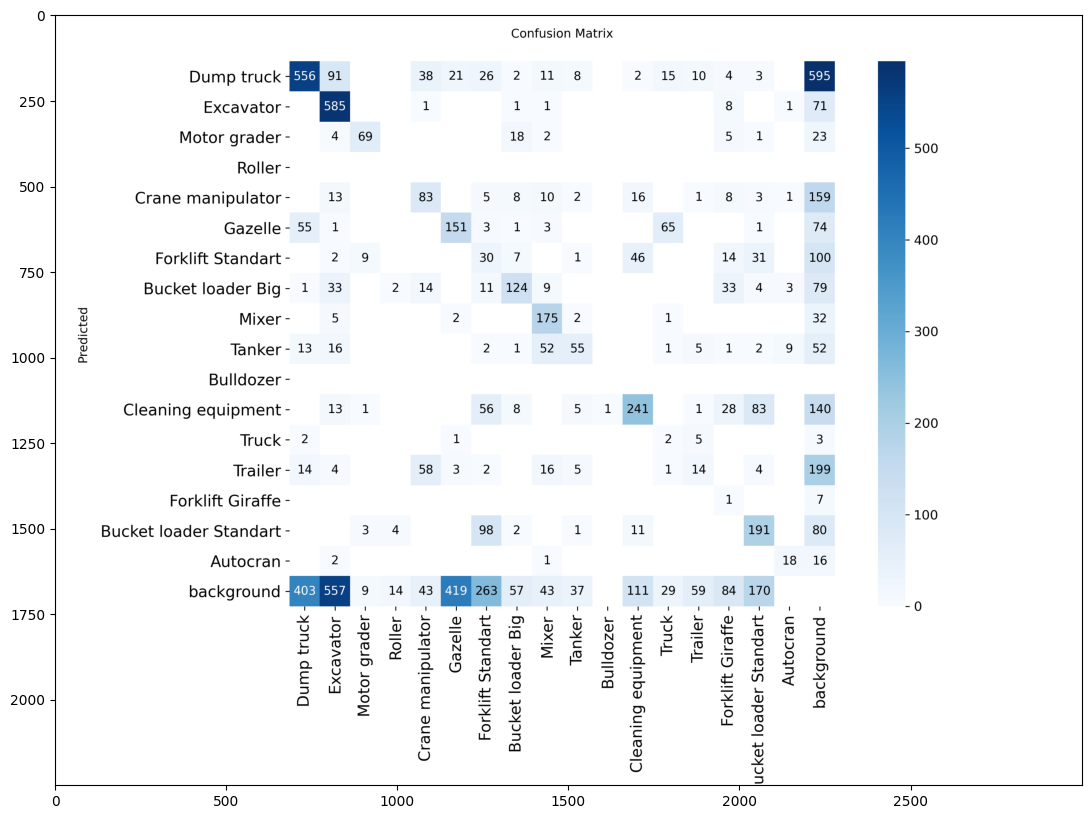

In [34]:
import os
import cv2
import matplotlib.pyplot as plt

image = "/content/runs/detect/construction_equipment3/confusion_matrix.png"
img=plt.imread(image)
plt.figure(figsize=(15, 10))
plt.imshow(img);

In [15]:
!zip -r  tuned_model.zip /content/runs/detect/construction_equipment3

  adding: content/runs/detect/construction_equipment3/ (stored 0%)
  adding: content/runs/detect/construction_equipment3/val_batch0_labels.jpg (deflated 5%)
  adding: content/runs/detect/construction_equipment3/train_batch1.jpg (deflated 7%)
  adding: content/runs/detect/construction_equipment3/BoxP_curve.png (deflated 3%)
  adding: content/runs/detect/construction_equipment3/train_batch2.jpg (deflated 11%)
  adding: content/runs/detect/construction_equipment3/val_batch2_labels.jpg (deflated 5%)
  adding: content/runs/detect/construction_equipment3/confusion_matrix.png (deflated 13%)
  adding: content/runs/detect/construction_equipment3/results.csv (deflated 57%)
  adding: content/runs/detect/construction_equipment3/val_batch0_pred.jpg (deflated 5%)
  adding: content/runs/detect/construction_equipment3/weights/ (stored 0%)
  adding: content/runs/detect/construction_equipment3/weights/last.pt (deflated 11%)
  adding: content/runs/detect/construction_equipment3/weights/best.pt (deflated 